In [5]:
import requests
import pandas as pd
import time

def fetch_all_records():
    url = "https://api.data.gov.in/resource/9ef84268-d588-465a-a308-a864a43d0070"
    api_key = "579b464db66ec23bdd0000010bf01bde54204d6044319017a24c0edb"  # YOUR KEY
    
    params = {
        "api-key": api_key,
        "format": "json",
        "limit": 1,
        "offset": 0
    }
    response = requests.get(url, params=params)
    total = response.json()['total']
    print(f"Total records available today: {total}")
    
    all_records = []
    batch_size = 500  # higher batch now since it's your own key
    
    for offset in range(0, total, batch_size):
        params['limit'] = batch_size
        params['offset'] = offset
        
        try:
            response = requests.get(url, params=params)
            records = response.json().get('records', [])
            all_records.extend(records)
            print(f"Fetched {len(all_records)}/{total} records...", end='\r')
            time.sleep(0.5)
        except Exception as e:
            print(f"\nError at offset {offset}, retrying...")
            time.sleep(2)
            continue
    
    df = pd.DataFrame(all_records)
    df.columns = ['State', 'District', 'Market', 'Commodity', 
                   'Variety', 'Grade', 'Arrival_Date', 
                   'Min_Price', 'Max_Price', 'Modal_Price']
    df['Min_Price'] = pd.to_numeric(df['Min_Price'])
    df['Max_Price'] = pd.to_numeric(df['Max_Price'])
    df['Modal_Price'] = pd.to_numeric(df['Modal_Price'])
    df['Arrival_Date'] = pd.to_datetime(df['Arrival_Date'], dayfirst=True)
    
    return df

df = fetch_all_records()
print(f"\n✅ Pipeline complete! {len(df)} records fetched")
print(df.head())

Total records available today: 5947
Fetched 3500/5947 records...
Error at offset 3500, retrying...

Error at offset 4000, retrying...
Fetched 4947/5947 records...
✅ Pipeline complete! 4947 records fetched
           State  District        Market              Commodity   Variety  \
0         Punjab    Mohali   Kharar APMC                  Onion     Other   
1         Punjab    Mohali   Kharar APMC                 Tomato    Tomato   
2         Punjab    Mohali   Kharar APMC               Capsicum  Capsicum   
3  Uttar Pradesh  Mirzapur  Ahirora APMC                  Wheat     Wheat   
4  Uttar Pradesh  Mirzapur  Ahirora APMC  Bhindi(Ladies Finger)    Bhindi   

     Grade Arrival_Date  Min_Price  Max_Price  Modal_Price  
0  Non-FAQ   2026-04-21     1300.0     2000.0       1500.0  
1  Non-FAQ   2026-04-21     1500.0     3000.0       2500.0  
2    Local   2026-04-21     1200.0     1500.0       1300.0  
3  Non-FAQ   2026-04-21     2425.0     2450.0       2450.0  
4   Medium   2026-04-21    

In [6]:
# Save what we have first
df.to_csv('/kaggle/working/live_market_data.csv', index=False)
print(f"✅ Saved {len(df)} records to CSV")
print(f"Date in data: {df['Arrival_Date'].unique()}")
print(f"States covered: {df['State'].nunique()}")
print(f"Commodities: {df['Commodity'].nunique()}")

✅ Saved 4947 records to CSV
Date in data: <DatetimeArray>
['2026-04-21 00:00:00']
Length: 1, dtype: datetime64[ns]
States covered: 26
Commodities: 198


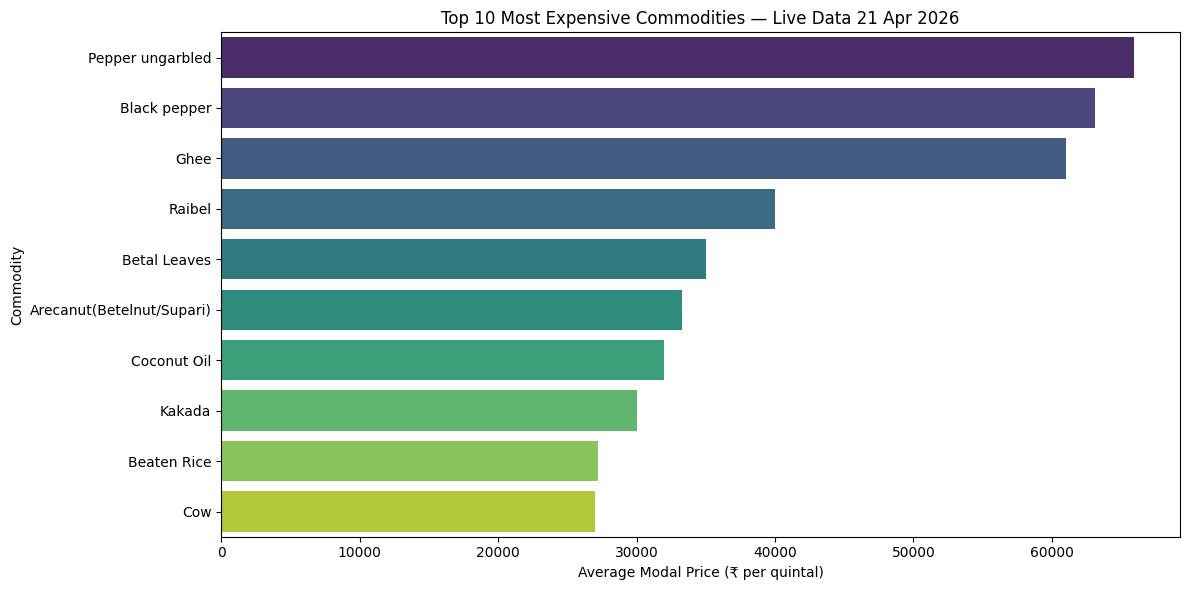

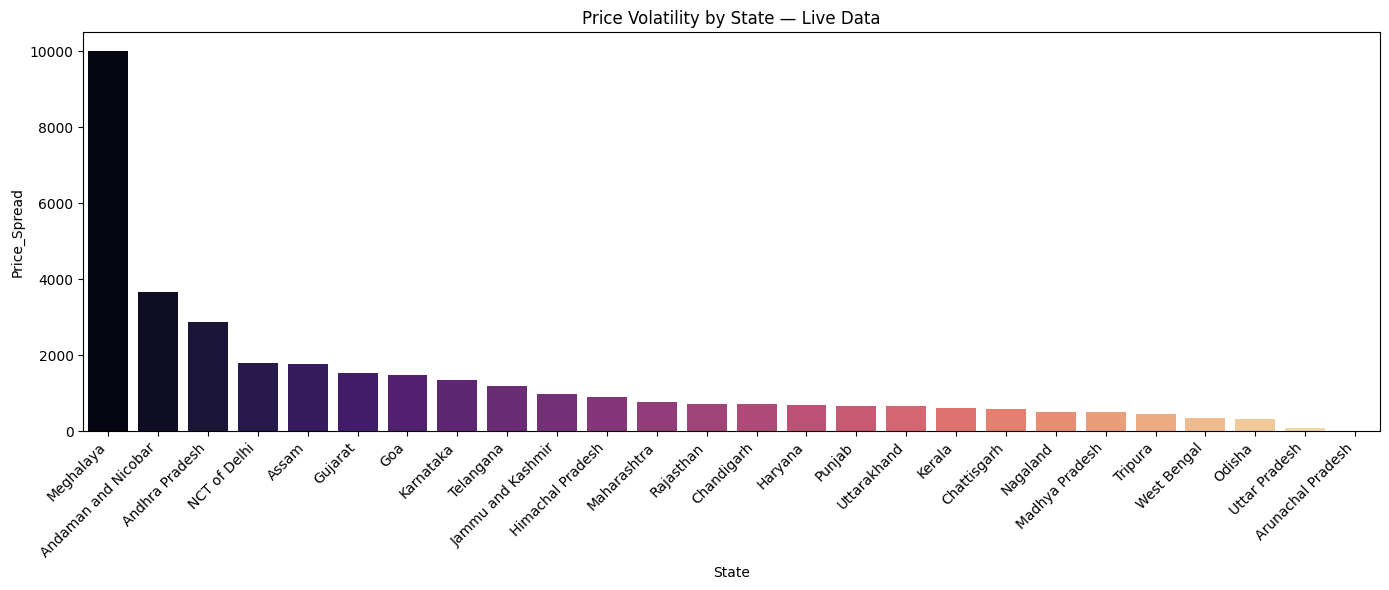


🌟 KEY INSIGHT — Arecanut Best Markets:
        State                     Market  Modal_Price
    Karnataka Shimoga(Theertahalli) APMC      51615.0
    Karnataka           Shikaripura APMC      49805.0
       Kerala              Kasargod APMC      45200.0
       Kerala            Kanjangadu APMC      44500.0
       Kerala             Payyannur APMC      42000.0
       Kerala               Irikkur APMC      38900.0
    Karnataka               Honnali APMC      26067.0
Uttar Pradesh               Lucknow APMC      23000.0
    Meghalaya              Shillong APMC      21000.0
    Karnataka Shimoga(Theertahalli) APMC      14000.0
    Karnataka               Honnali APMC      10000.0

💰 Price gap between best and worst market: ₹41,615 per quintal
A farmer selling in the wrong market loses this amount per quintal!


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Price Spread (volatility)
df['Price_Spread'] = df['Max_Price'] - df['Min_Price']

# 2. Top 10 expensive commodities
top_commodities = (df.groupby('Commodity')['Modal_Price']
                     .mean()
                     .sort_values(ascending=False)
                     .head(10))

plt.figure(figsize=(12,6))
sns.barplot(x=top_commodities.values, y=top_commodities.index,
            hue=top_commodities.index, palette='viridis', legend=False)
plt.title('Top 10 Most Expensive Commodities — Live Data 21 Apr 2026')
plt.xlabel('Average Modal Price (₹ per quintal)')
plt.tight_layout()
plt.savefig('top_commodities_live.png')
plt.show()

# 3. Most volatile states
state_volatility = (df.groupby('State')['Price_Spread']
                      .mean()
                      .sort_values(ascending=False)
                      .reset_index())

plt.figure(figsize=(14,6))
sns.barplot(data=state_volatility, x='State', y='Price_Spread',
            hue='State', palette='magma', legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Price Volatility by State — Live Data')
plt.tight_layout()
plt.savefig('volatility_live.png')
plt.show()

# 4. Key insight — best market for Arecanut
arecanut = df[df['Commodity'] == 'Arecanut(Betelnut/Supari)']
print("\n🌟 KEY INSIGHT — Arecanut Best Markets:")
print(arecanut[['State', 'Market', 'Modal_Price']]
      .sort_values('Modal_Price', ascending=False)
      .to_string(index=False))

gap = arecanut['Modal_Price'].max() - arecanut['Modal_Price'].min()
print(f"\n💰 Price gap between best and worst market: ₹{gap:,.0f} per quintal")
print("A farmer selling in the wrong market loses this amount per quintal!")

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error

# Encode categorical columns
le_state = LabelEncoder()
le_commodity = LabelEncoder()

df['State_encoded'] = le_state.fit_transform(df['State'])
df['Commodity_encoded'] = le_commodity.fit_transform(df['Commodity'])

X = df[['State_encoded', 'Commodity_encoded', 'Min_Price', 'Max_Price']]
y = df['Modal_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

print(f"✅ Model trained successfully!")
print(f"Mean Absolute Error: ₹{mae:,.0f}")
print(f"This means predictions are off by ₹{mae:,.0f} on average")

✅ Model trained successfully!
Mean Absolute Error: ₹138
This means predictions are off by ₹138 on average
